In [1]:
import os
import gc
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import cross_validate

import xgboost as xgb

In [2]:
df = pd.read_csv("data/03_panel_instability.csv")
df = df.sort_values(["COUNTRY", "YEAR"]).copy()

print(f"Loaded: {df.shape}")
print(f"Countries: {df['COUNTRY'].nunique()}")
print(f"Years: {df['YEAR'].min()}-{df['YEAR'].max()}")

if "Crisis_Flag" not in df.columns:
    raise ValueError(
        "Crisis_Flag is missing. Go back to "
        "02_layer1_instability_index.ipynb, create Crisis_Flag, "
        "and resave data/03_panel_instability.csv."
    )

print("\nCrisis flag distribution:")
print(df["Crisis_Flag"].value_counts(dropna=False))

print("\nCrisis flag rate:")
print(df["Crisis_Flag"].value_counts(normalize=True).round(3))

Loaded: (5157, 116)
Countries: 175
Years: 1997-2026

Crisis flag distribution:
Crisis_Flag
0    4125
1    1032
Name: count, dtype: int64

Crisis flag rate:
Crisis_Flag
0    0.8
1    0.2
Name: proportion, dtype: float64


In [3]:
base_feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

volatility_cols = [
    col for col in [
        "GDP_Growth_rollstd3",
        "Inflation_rollstd3",
        "Exports_rollstd3",
        "Imports_rollstd3",
        "Fiscal_Balance_rollstd3",
        "Current_Account_rollstd3",
        "Debt_rollstd3",
        "Revenue_rollstd3",
        "Expenditure_rollstd3",
        "Savings_rollstd3",
        "Investment_rollstd3",
    ]
    if col in df.columns
]

# Country-history features
df["Country_GDP_Mean_lag1"] = (
    df.groupby("COUNTRY")["GDP_Growth"]
    .transform(lambda x: x.shift(1).expanding(min_periods=3).mean())
)

df["Country_GDP_Std_lag1"] = (
    df.groupby("COUNTRY")["GDP_Growth"]
    .transform(lambda x: x.shift(1).expanding(min_periods=3).std())
)

df["GDP_vs_Country_Mean_lag1"] = (
    df["GDP_Growth_lag1"] - df["Country_GDP_Mean_lag1"]
)

df["Year_Trend"] = df["YEAR"] - df["YEAR"].min()

country_history_cols = [
    "Country_GDP_Mean_lag1",
    "Country_GDP_Std_lag1",
    "GDP_vs_Country_Mean_lag1",
    "Year_Trend",
]

feature_cols = (
    base_feature_cols
    + volatility_cols
    + country_history_cols
)

df_model = df.dropna(
    subset=feature_cols + ["Crisis_Flag"]
).copy()

print(f"Model dataset: {df_model.shape}")
print(f"Features used: {len(feature_cols)}")

Model dataset: (4632, 120)
Features used: 28


In [4]:
TRAIN_END = 2019
COVID_YEARS = [2020, 2021]
TEST_YEARS = [2022, 2023]
SCENARIO_YEARS = [2024, 2025, 2026]

train = df_model[df_model["YEAR"] <= TRAIN_END].copy()

test = df_model[
    df_model["YEAR"].isin(TEST_YEARS)
].copy()

covid_test = df_model[
    df_model["YEAR"].isin(COVID_YEARS)
].copy()

scenario = df_model[
    df_model["YEAR"].isin(SCENARIO_YEARS)
].copy()

X_train = train[feature_cols].to_numpy()
y_train = train["Crisis_Flag"].astype(int).to_numpy()

X_test = test[feature_cols].to_numpy()
y_test = test["Crisis_Flag"].astype(int).to_numpy()

X_covid = covid_test[feature_cols].to_numpy()
y_covid = covid_test["Crisis_Flag"].astype(int).to_numpy()

X_scenario = scenario[feature_cols].to_numpy()

print(f"Train: {train['YEAR'].min()}-{train['YEAR'].max()} | n={len(train)}")
print(f"Observed test: {test['YEAR'].min()}-{test['YEAR'].max()} | n={len(test)}")
print(f"COVID stress: {covid_test['YEAR'].min()}-{covid_test['YEAR'].max()} | n={len(covid_test)}")
print(f"Scenario projection: {scenario['YEAR'].min()}-{scenario['YEAR'].max()} | n={len(scenario)}")

print("\nTrain crisis rate:", round(y_train.mean(), 3))
print("Test crisis rate :", round(y_test.mean(), 3))

Train: 2000-2019 | n=3427
Observed test: 2022-2023 | n=346
COVID stress: 2020-2021 | n=346
Scenario projection: 2024-2026 | n=513

Train crisis rate: 0.177
Test crisis rate : 0.5


In [5]:
train_years = train["YEAR"].to_numpy(copy=False)

validation_years = [2015, 2016, 2017, 2018, 2019]

time_splits = []

for validation_year in validation_years:
    train_idx = np.flatnonzero(train_years < validation_year)
    valid_idx = np.flatnonzero(train_years == validation_year)

    if len(train_idx) > 0 and len(valid_idx) > 0:
        time_splits.append((train_idx, valid_idx))

        print(
            f"Fold {validation_year}: "
            f"train={len(train_idx)}, validation={len(valid_idx)}"
        )

Fold 2015: train=2559, validation=173
Fold 2016: train=2732, validation=173
Fold 2017: train=2905, validation=174
Fold 2018: train=3079, validation=174
Fold 2019: train=3253, validation=174


In [6]:
positive_rate = y_train.mean()
negative_rate = 1 - positive_rate

scale_pos_weight = (
    negative_rate / positive_rate
    if positive_rate > 0
    else 1
)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        ),
        "scaled": True,
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
        "scaled": False,
    },

    "Extra Trees": {
        "model": ExtraTreesClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        ),
        "scaled": False,
    },

    "XGBoost": {
        "model": xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=3.0,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0,
            n_jobs=1,
        ),
        "scaled": False,
    },
}

print("Models defined:")
for name in models:
    print(" -", name)

Models defined:
 - Logistic Regression
 - Random Forest
 - Extra Trees
 - XGBoost


In [7]:
trained = {}
cv_rows = []

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

for name, cfg in models.items():
    print(f"\nTraining {name}...")

    estimator = clone(cfg["model"])

    if cfg["scaled"]:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
    else:
        pipeline = Pipeline([
            ("model", estimator),
        ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=time_splits,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    row = {
        "Model": name,
        "CV_Accuracy": round(scores["test_accuracy"].mean(), 3),
        "CV_Precision": round(scores["test_precision"].mean(), 3),
        "CV_Recall": round(scores["test_recall"].mean(), 3),
        "CV_F1": round(scores["test_f1"].mean(), 3),
        "CV_ROC_AUC": round(scores["test_roc_auc"].mean(), 3),
    }

    cv_rows.append(row)

    pipeline.fit(X_train, y_train)
    trained[name] = pipeline

    model_path = f"models/ews_{name.lower().replace(' ', '_')}.pkl"
    joblib.dump(pipeline, model_path)

    print(
        f"{name:<20} "
        f"CV F1={row['CV_F1']:.3f} | "
        f"CV ROC-AUC={row['CV_ROC_AUC']:.3f}"
    )

    gc.collect()

cv_results_df = pd.DataFrame(cv_rows)

cv_results_df.to_csv(
    "data/ews_cv_results.csv",
    index=False,
)

display(cv_results_df.sort_values("CV_ROC_AUC", ascending=False))


Training Logistic Regression...


Logistic Regression  CV F1=0.731 | CV ROC-AUC=0.976

Training Random Forest...
Random Forest        CV F1=0.715 | CV ROC-AUC=0.975

Training Extra Trees...
Extra Trees          CV F1=0.647 | CV ROC-AUC=0.975

Training XGBoost...
XGBoost              CV F1=0.758 | CV ROC-AUC=0.978


,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC
3,XGBoost,0.956,0.704,0.836,0.758,0.978
0,Logistic Regression,0.948,0.638,0.864,0.731,0.976
1,Random Forest,0.942,0.601,0.901,0.715,0.975
2,Extra Trees,0.921,0.512,0.899,0.647,0.975


In [8]:
def evaluate_classifier(name, y_true, y_pred, y_prob, period):
    return {
        "Model": name,
        "Period": period,
        "N": len(y_true),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 3),
        "ROC_AUC": round(roc_auc_score(y_true, y_prob), 3),
    }


test_rows = []

for name, pipeline in trained.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    test_rows.append(
        evaluate_classifier(
            name,
            y_test,
            y_pred,
            y_prob,
            "Observed test (2022-23)",
        )
    )

test_results_df = pd.DataFrame(test_rows)

test_results_df.to_csv(
    "data/ews_test_results.csv",
    index=False,
)

display(test_results_df.sort_values("ROC_AUC", ascending=False))

,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
2,Extra Trees,Observed test (2022-23),346,0.838,0.791,0.919,0.850,0.930
0,Logistic Regression,Observed test (2022-23),346,0.841,0.878,0.792,0.833,0.923
3,XGBoost,Observed test (2022-23),346,0.835,0.892,0.763,0.822,0.922
1,Random Forest,Observed test (2022-23),346,0.827,0.809,0.855,0.831,0.920


In [9]:
best_model_name = (
    test_results_df
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]["Model"]
)

best_model = trained[best_model_name]

best_prob = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

print(f"Best EWS model: {best_model_name}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification report:")
print(classification_report(y_test, best_pred, zero_division=0))

Best EWS model: Extra Trees

Confusion matrix:
[[131  42]
 [ 14 159]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82       173
           1       0.79      0.92      0.85       173

    accuracy                           0.84       346
   macro avg       0.85      0.84      0.84       346
weighted avg       0.85      0.84      0.84       346



In [10]:
covid_rows = []

for name, pipeline in trained.items():
    y_prob = pipeline.predict_proba(X_covid)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    covid_rows.append(
        evaluate_classifier(
            name,
            y_covid,
            y_pred,
            y_prob,
            "COVID stress test (2020-21)",
        )
    )

covid_results_df = pd.DataFrame(covid_rows)

covid_results_df.to_csv(
    "data/ews_covid_stress_results.csv",
    index=False,
)

display(covid_results_df.sort_values("ROC_AUC", ascending=False))

,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
2,Extra Trees,COVID stress test (2020-21),346,0.821,0.879,0.518,0.652,0.939
0,Logistic Regression,COVID stress test (2020-21),346,0.809,0.926,0.446,0.602,0.937
3,XGBoost,COVID stress test (2020-21),346,0.801,0.891,0.438,0.587,0.932
1,Random Forest,COVID stress test (2020-21),346,0.812,0.912,0.464,0.615,0.929


In [11]:
scenario_output = scenario[
    ["COUNTRY", "YEAR"]
].reset_index(drop=True)

for name, pipeline in trained.items():
    prob = pipeline.predict_proba(X_scenario)[:, 1]
    pred = (prob >= 0.5).astype(int)

    safe_name = name.replace(" ", "_")

    scenario_output[f"{safe_name}_Crisis_Prob"] = prob
    scenario_output[f"{safe_name}_Crisis_Class"] = pred

scenario_output.to_csv(
    "data/ews_scenario_2024_2026.csv",
    index=False,
)

display(scenario_output.head())

print("Saved: data/ews_scenario_2024_2026.csv")

,COUNTRY,YEAR,Logistic_Regression_Crisis_Prob,Logistic_Regression_Crisis_Class,Random_Forest_Crisis_Prob,Random_Forest_Crisis_Class,Extra_Trees_Crisis_Prob,Extra_Trees_Crisis_Class,XGBoost_Crisis_Prob,XGBoost_Crisis_Class
0,"Afghanistan, Islamic Republic of",2024,0.145176,0,0.340547,0,0.557948,1,0.204753,0
1,"Afghanistan, Islamic Republic of",2025,0.354088,0,0.461153,0,0.614331,1,0.469222,0
2,Albania,2024,0.372211,0,0.377700,0,0.490547,0,0.303869,0
3,Albania,2025,0.025983,0,0.077037,0,0.162343,0,0.014056,0
4,Albania,2026,0.001149,0,0.002628,0,0.020841,0,0.000845,0


Saved: data/ews_scenario_2024_2026.csv


In [12]:
best_estimator = best_model.named_steps["model"]

if hasattr(best_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": best_estimator.feature_importances_,
    }).sort_values("Importance", ascending=False)

elif hasattr(best_estimator, "coef_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": best_estimator.coef_[0],
        "Abs_Coefficient": np.abs(best_estimator.coef_[0]),
    }).sort_values("Abs_Coefficient", ascending=False)

else:
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
    })

importance_df.to_csv(
    "data/ews_feature_importance.csv",
    index=False,
)

display(importance_df.head(15))

,Feature,Importance
12,Instability_Index_lag1,0.201712
18,Current_Account_rollstd3,0.199078
17,Fiscal_Balance_rollstd3,0.138436
14,Inflation_rollstd3,0.112630
13,GDP_Growth_rollstd3,0.106512
19,Debt_rollstd3,0.101755
27,Year_Trend,0.016052
21,Expenditure_rollstd3,0.013552
22,Savings_rollstd3,0.010212
20,Revenue_rollstd3,0.009898


In [13]:
# ============================================================
# Final EWS output using best model
# ============================================================

best_model_name = (
    test_results_df
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]["Model"]
)

best_model = trained[best_model_name]

scenario_prob = best_model.predict_proba(X_scenario)[:, 1]

final_ews = scenario[
    ["COUNTRY", "YEAR", "Instability_Index_lag1"]
].reset_index(drop=True)

final_ews["Best_EWS_Model"] = best_model_name
final_ews["Crisis_Probability"] = scenario_prob

final_ews["Risk_Level"] = pd.cut(
    final_ews["Crisis_Probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Moderate", "High"],
    include_lowest=True,
)

final_ews["Early_Warning_Flag"] = (
    final_ews["Crisis_Probability"] >= 0.6
).astype(int)

final_ews = final_ews.sort_values(
    ["YEAR", "Crisis_Probability"],
    ascending=[True, False],
)

final_ews.to_csv(
    "data/final_ews_2024_2026.csv",
    index=False,
)

final_ews.head(20)

print("Saved: data/final_ews_2024_2026.csv")

Saved: data/final_ews_2024_2026.csv


In [14]:
final_ews.head(20)

,COUNTRY,YEAR,Instability_Index_lag1,Best_EWS_Model,Crisis_Probability,Risk_Level,Early_Warning_Flag
427,"South Sudan, Republic of",2024,92.455175,Extra Trees,0.970195,High,1
485,Ukraine,2024,81.991235,Extra Trees,0.966918,High,1
77,Cabo Verde,2024,95.709271,Extra Trees,0.936428,High,1
313,Mongolia,2024,84.436090,Extra Trees,0.920471,High,1
440,Sudan,2024,85.971395,Extra Trees,0.910661,High,1
503,"Venezuela, República Bolivariana de",2024,72.992682,Extra Trees,0.874641,High,1
361,"Palau, Republic of",2024,68.007953,Extra Trees,0.866043,High,1
26,"Bahamas, The",2024,75.699617,Extra Trees,0.857313,High,1
355,Oman,2024,62.751526,Extra Trees,0.847689,High,1
266,Lebanon,2024,93.616496,Extra Trees,0.828454,High,1


In [15]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

ews = pd.read_csv("data/final_ews_2024_2026.csv")

df = pd.read_csv("data/03_panel_instability.csv")

projection_actual = df[
    df["YEAR"].isin([2024, 2025, 2026])
][
    [
        "COUNTRY",
        "YEAR",
        "GDP_Growth",
        "Instability_Index",
        "Instability_Index_lag1",
        "Stability_Category",
        "Crisis_Flag",
    ]
].copy()

comparison = ews.merge(
    projection_actual,
    on=["COUNTRY", "YEAR"],
    how="left",
    suffixes=("_Predicted", "_IMF_Projection"),
)

comparison["Prediction_Correct"] = (
    comparison["Early_Warning_Flag"]
    == comparison["Crisis_Flag"]
).astype(int)

comparison.to_csv(
    "data/ews_vs_imf_projection_comparison_2024_2026.csv",
    index=False,
)

print("Saved: data/ews_vs_imf_projection_comparison_2024_2026.csv")

comparison.head()

Saved: data/ews_vs_imf_projection_comparison_2024_2026.csv


,COUNTRY,YEAR,Instability_Index_lag1_Predicted,Best_EWS_Model,Crisis_Probability,Risk_Level,Early_Warning_Flag,GDP_Growth,Instability_Index,Instability_Index_lag1_IMF_Projection,Stability_Category,Crisis_Flag,Prediction_Correct
0,"South Sudan, Republic of",2024,92.455175,Extra Trees,0.970195,High,1,-26.141,91.077438,92.455175,Crisis,1,1
1,Ukraine,2024,81.991235,Extra Trees,0.966918,High,1,3.248,74.441967,81.991235,Crisis,1,1
2,Cabo Verde,2024,95.709271,Extra Trees,0.936428,High,1,7.244,79.786016,95.709271,Crisis,1,1
3,Mongolia,2024,84.436090,Extra Trees,0.920471,High,1,5.122,61.931889,84.436090,Crisis,1,1
4,Sudan,2024,85.971395,Extra Trees,0.910661,High,1,-23.363,65.936985,85.971395,Crisis,1,1


In [16]:
y_true = comparison["Crisis_Flag"].astype(int)
y_pred = comparison["Early_Warning_Flag"].astype(int)
y_prob = comparison["Crisis_Probability"].astype(float)

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1": f1_score(y_true, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_true, y_prob),
}

metrics_df = pd.DataFrame([metrics]).round(3)

display(metrics_df)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report:")
print(classification_report(y_true, y_pred, zero_division=0))

metrics_df.to_csv(
    "data/ews_projection_metrics_2024_2026.csv",
    index=False,
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.91,0.598,0.892,0.716,0.963


Confusion matrix:
[[409  39]
 [  7  58]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.95       448
           1       0.60      0.89      0.72        65

    accuracy                           0.91       513
   macro avg       0.79      0.90      0.83       513
weighted avg       0.93      0.91      0.92       513



In [17]:
year_rows = []

for year, sub in comparison.groupby("YEAR"):
    y_true_y = sub["Crisis_Flag"].astype(int)
    y_pred_y = sub["Early_Warning_Flag"].astype(int)
    y_prob_y = sub["Crisis_Probability"].astype(float)

    row = {
        "YEAR": year,
        "N": len(sub),
        "Actual_Crisis_Rate": y_true_y.mean(),
        "Predicted_Warning_Rate": y_pred_y.mean(),
        "Accuracy": accuracy_score(y_true_y, y_pred_y),
        "Precision": precision_score(y_true_y, y_pred_y, zero_division=0),
        "Recall": recall_score(y_true_y, y_pred_y, zero_division=0),
        "F1": f1_score(y_true_y, y_pred_y, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true_y, y_prob_y),
    }

    year_rows.append(row)

year_metrics_df = pd.DataFrame(year_rows).round(3)

display(year_metrics_df)

year_metrics_df.to_csv(
    "data/ews_projection_yearwise_metrics.csv",
    index=False,
)

,YEAR,N,Actual_Crisis_Rate,Predicted_Warning_Rate,Accuracy,Precision,Recall,F1,ROC_AUC
0,2024,173,0.191,0.283,0.850,0.571,0.848,0.683,0.918
1,2025,171,0.117,0.170,0.924,0.621,0.900,0.735,0.970
2,2026,169,0.071,0.112,0.959,0.632,1.000,0.774,0.993


In [18]:
top_warnings = comparison.sort_values(
    ["YEAR", "Crisis_Probability"],
    ascending=[True, False],
)[
    [
        "COUNTRY",
        "YEAR",
        "Crisis_Probability",
        "Risk_Level",
        "Early_Warning_Flag",
        "Crisis_Flag",
        "Stability_Category",
        "GDP_Growth",
        "Instability_Index",
        "Prediction_Correct",
    ]
]

display(top_warnings.head(1000))

top_warnings.to_csv(
    "data/ews_top_warning_countries_2024_2026.csv",
    index=False,
)

,COUNTRY,YEAR,Crisis_Probability,Risk_Level,Early_Warning_Flag,Crisis_Flag,Stability_Category,GDP_Growth,Instability_Index,Prediction_Correct
0,"South Sudan, Republic of",2024,0.970195,High,1,1,Crisis,-26.141,91.077438,1
1,Ukraine,2024,0.966918,High,1,1,Crisis,3.248,74.441967,1
2,Cabo Verde,2024,0.936428,High,1,1,Crisis,7.244,79.786016,1
3,Mongolia,2024,0.920471,High,1,1,Crisis,5.122,61.931889,1
4,Sudan,2024,0.910661,High,1,1,Crisis,-23.363,65.936985,1
...,...,...,...,...,...,...,...,...,...,...
508,South Africa,2026,0.012925,Low,0,0,Stable,1.049,11.254238,1
509,Indonesia,2026,0.012507,Low,0,0,Stable,4.950,0.986939,1
510,"Tanzania, United Republic of",2026,0.012365,Low,0,0,Stable,5.940,10.921391,1
511,Jordan,2026,0.011677,Low,0,0,Stable,2.748,3.826652,1


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

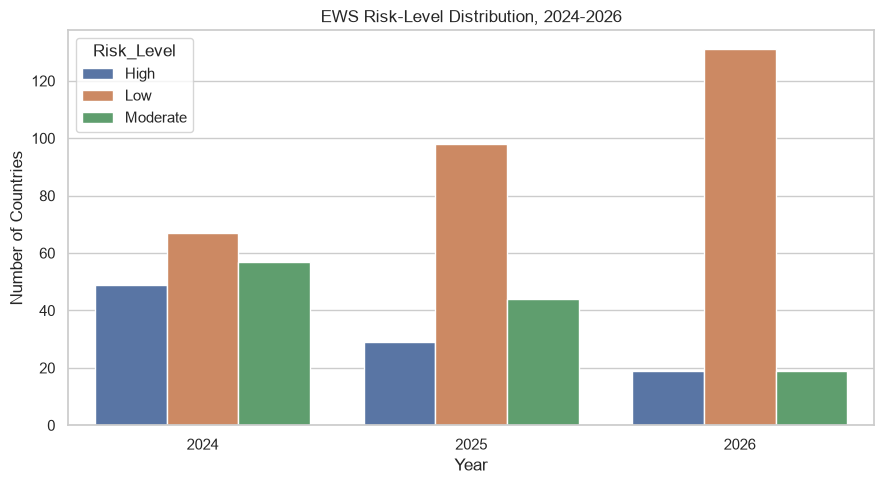

In [20]:
risk_counts = (
    comparison
    .groupby(["YEAR", "Risk_Level"])
    .size()
    .reset_index(name="Count")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_counts,
    x="YEAR",
    y="Count",
    hue="Risk_Level",
    order=[2024, 2025, 2026],
)

plt.title("EWS Risk-Level Distribution, 2024-2026")
plt.ylabel("Number of Countries")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig("ews_risk_distribution_2024_2026.png", dpi=150)
plt.show()

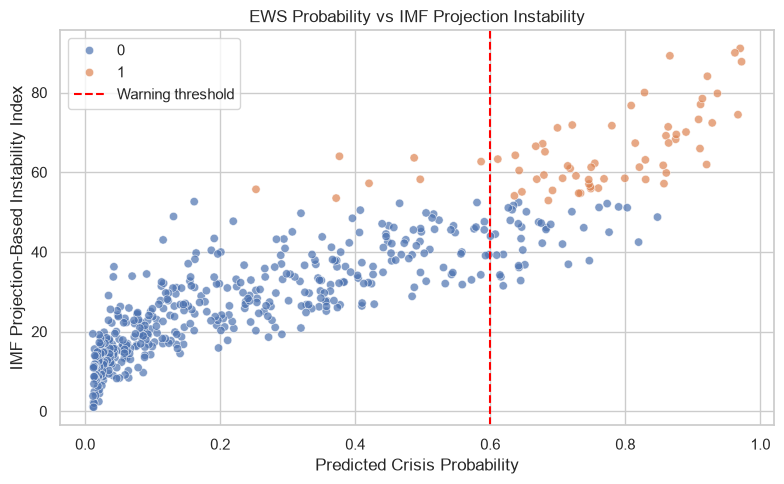

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=comparison,
    x="Crisis_Probability",
    y="Instability_Index",
    hue="Crisis_Flag",
    alpha=0.7,
)

plt.axvline(0.6, color="red", linestyle="--", label="Warning threshold")
plt.title("EWS Probability vs IMF Projection Instability")
plt.xlabel("Predicted Crisis Probability")
plt.ylabel("IMF Projection-Based Instability Index")
plt.legend()
plt.tight_layout()
plt.savefig("ews_probability_vs_instability.png", dpi=150)
plt.show()

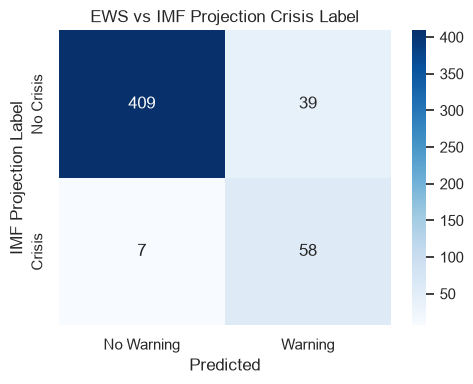

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Warning", "Warning"],
    yticklabels=["No Crisis", "Crisis"],
)

plt.title("EWS vs IMF Projection Crisis Label")
plt.xlabel("Predicted")
plt.ylabel("IMF Projection Label")
plt.tight_layout()
plt.savefig("ews_confusion_matrix_2024_2026.png", dpi=150)
plt.show()

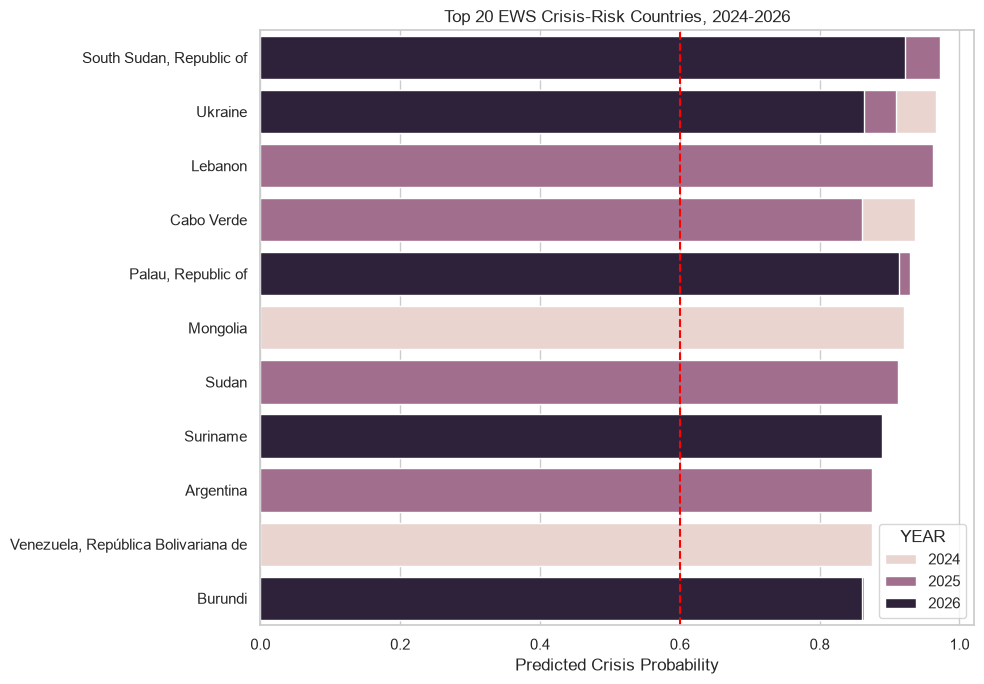

In [23]:
top20 = comparison.sort_values(
    "Crisis_Probability",
    ascending=False,
).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20,
    y="COUNTRY",
    x="Crisis_Probability",
    hue="YEAR",
    dodge=False,
)

plt.axvline(0.6, color="red", linestyle="--")
plt.title("Top 20 EWS Crisis-Risk Countries, 2024-2026")
plt.xlabel("Predicted Crisis Probability")
plt.ylabel("")
plt.tight_layout()
plt.savefig("ews_top20_risk_countries.png", dpi=150)
plt.show()

Because 2024–2026 values in the WEO dataset are IMF projections, the EWS forecasts are validated against IMF projection-derived instability labels rather than finalized realized outcomes. This provides a scenario-consistency check, not a definitive real-world accuracy test.

,COUNTRY,YEAR,Crisis_Probability,Risk_Level,Early_Warning_Flag,Crisis_Flag,Stability_Category,GDP_Growth,Instability_Index
512,Australia,2026,0.011387,Low,0,0,Moderate,2.009,19.425494
511,Jordan,2026,0.011677,Low,0,0,Stable,2.748,3.826652
343,Indonesia,2025,0.011700,Low,0,0,Stable,5.108,1.131944
510,"Tanzania, United Republic of",2026,0.012365,Low,0,0,Stable,5.940,10.921391
342,Switzerland,2025,0.012491,Low,0,0,Stable,1.272,2.206824
509,Indonesia,2026,0.012507,Low,0,0,Stable,4.950,0.986939
508,South Africa,2026,0.012925,Low,0,0,Stable,1.049,11.254238
507,Malaysia,2026,0.013036,Low,0,0,Stable,4.700,6.843213
506,Uruguay,2026,0.013192,Low,0,0,Stable,1.800,8.694512
505,Switzerland,2026,0.013224,Low,0,0,Stable,1.342,2.028194


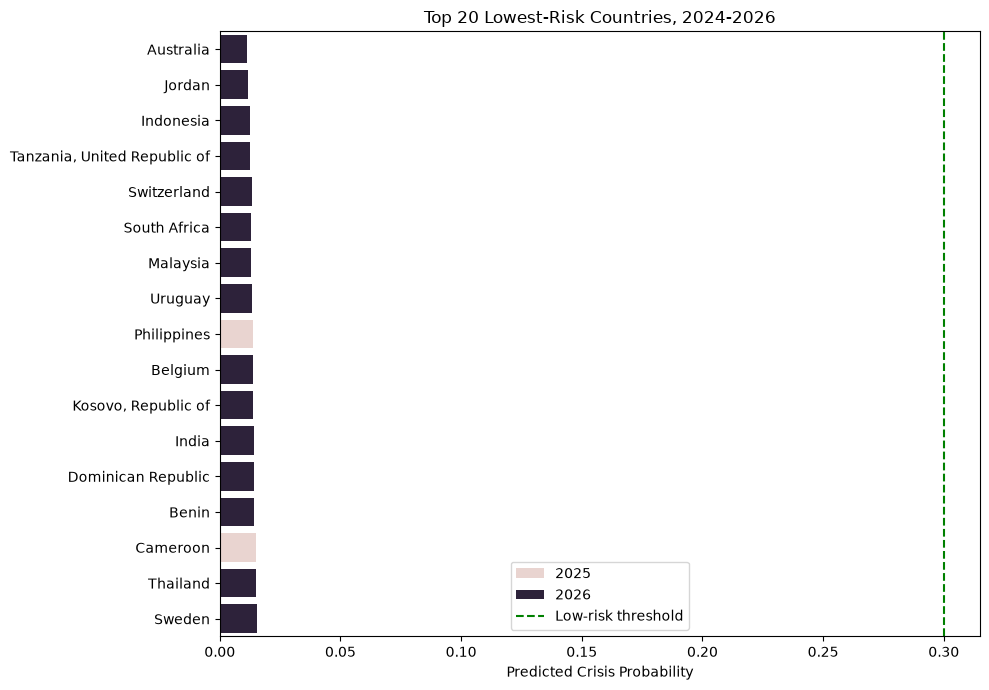

Saved:
  data/ews_top20_low_risk_countries_2024_2026.csv
  ews_top20_low_risk_countries.png


In [1]:
# ============================================================
# Top 20 Lowest-Risk / Non-Crisis Countries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

comparison = pd.read_csv(
    "data/ews_vs_imf_projection_comparison_2024_2026.csv"
)

# Lowest predicted crisis probability
low_risk = comparison.sort_values(
    "Crisis_Probability",
    ascending=True
).head(20)

low_risk_table = low_risk[
    [
        "COUNTRY",
        "YEAR",
        "Crisis_Probability",
        "Risk_Level",
        "Early_Warning_Flag",
        "Crisis_Flag",
        "Stability_Category",
        "GDP_Growth",
        "Instability_Index",
    ]
].copy()

low_risk_table.to_csv(
    "data/ews_top20_low_risk_countries_2024_2026.csv",
    index=False,
)

display(low_risk_table)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=low_risk,
    y="COUNTRY",
    x="Crisis_Probability",
    hue="YEAR",
    dodge=False,
)

plt.axvline(
    0.3,
    color="green",
    linestyle="--",
    label="Low-risk threshold",
)

plt.title("Top 20 Lowest-Risk Countries, 2024-2026")
plt.xlabel("Predicted Crisis Probability")
plt.ylabel("")
plt.legend()
plt.tight_layout()

plt.savefig(
    "ews_top20_low_risk_countries.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print("  data/ews_top20_low_risk_countries_2024_2026.csv")
print("  ews_top20_low_risk_countries.png")